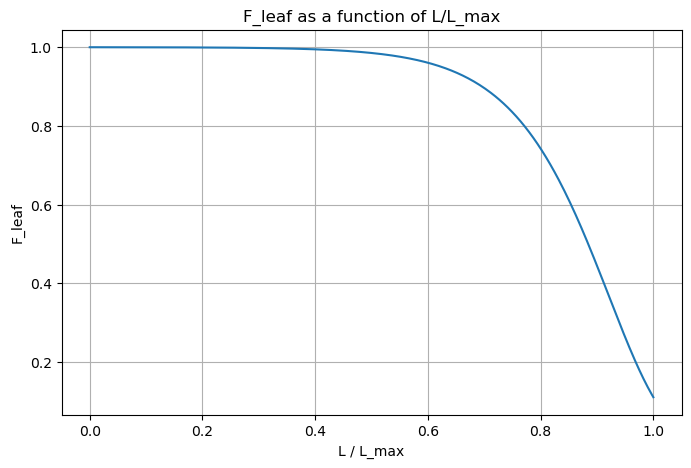

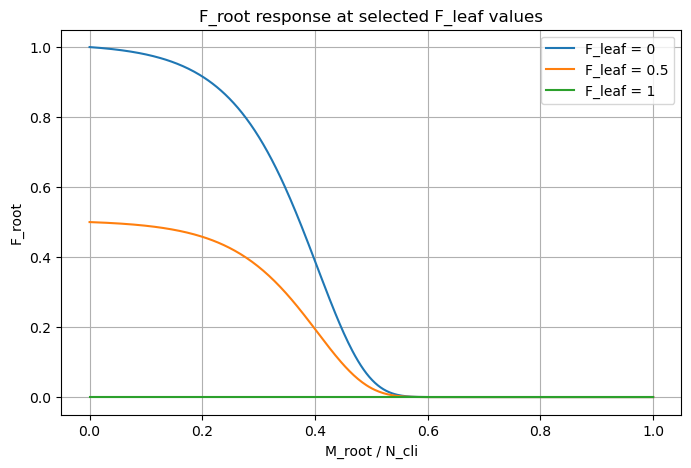

interactive(children=(FloatSlider(value=0.25, description='gamma_root', max=1.0, min=0.05, step=0.05), FloatSl…

In [ ]:
"""Plot the phenology equations in the new Noah-MP in 

Gim, H.-J., Park, S. K., Kang, M., Thakuri, B. M., Kim, J., and Ho, C.-H.: 
    An improved parameterization of the allocation of assimilated carbon 
    to plant parts in vegetation dynamics for Noah-MP, Journal of 
    Advances in Modeling Earth Systems, 9, 1776-1794, 
    https://doi.org/10.1002/2016MS000890, 2017.
"""

# ------------------------------------------------------------
# Allocation functions and plotting (static + interactive)
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Functions
# -----------------------

def F_leaf(L_over_Lmax):
    return np.exp(0.0001 * (1 - np.exp(10 * L_over_Lmax)))

def F_root(M_over_N, F_leaf_value, gamma_root=0.25, S_root=2):
    exponent = 5.7 * M_over_N / (gamma_root * S_root)
    return np.exp(0.01 * (1 - np.exp(exponent))) * (1 - F_leaf_value)


# -----------------------
# Static plots
# -----------------------

# Ranges
L_over_Lmax = np.linspace(0, 1, 400)
M_over_N = np.linspace(0, 1, 400)

# Compute curves
Fleaf_vals = F_leaf(L_over_Lmax)
Fleaf_set = [0, 0.5, 1]
Froot_vals = {f: F_root(M_over_N, f) for f in Fleaf_set}

# Plot F_leaf
plt.figure(figsize=(8,5))
plt.plot(L_over_Lmax, Fleaf_vals)
plt.xlabel("L / L_max")
plt.ylabel("F_leaf")
plt.title("F_leaf as a function of L/L_max")
plt.grid(True)
plt.show()

# Plot F_root for selected F_leaf values
plt.figure(figsize=(8,5))
for f in Fleaf_set:
    plt.plot(M_over_N, Froot_vals[f], label=f"F_leaf = {f}")
plt.xlabel("M_root / N_cli")
plt.ylabel("F_root")
plt.title("F_root response at selected F_leaf values")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# OPTIONAL: Interactive widgets
# ------------------------------------------------------------
# Only run this section if you want interactive controls.

try:
    from ipywidgets import interact, FloatSlider

    @interact(
        gamma_root=FloatSlider(min=0.05, max=1, step=0.05, value=0.25),
        S_root=FloatSlider(min=0.5, max=5, step=0.1, value=2)
    )
    def interactive_Froot(gamma_root, S_root):
        M = np.linspace(0,1,400)
        Fr_0 = F_root(M, 0, gamma_root, S_root)
        Fr_0_5 = F_root(M, 0.5, gamma_root, S_root)
        Fr_1 = F_root(M, 1, gamma_root, S_root)
        plt.figure(figsize=(7,5))
        plt.plot(M, Fr_0, label = "F_root @ F_leaf = 0")
        plt.plot(M, Fr_0_5, label = "F_root @ F_leaf = 0.5")
        plt.plot(M, Fr_1, label = "F_root @ F_leaf = 1")
        plt.legend()
        plt.xlabel("M_root / N_cli")
        plt.ylim(0,1.05)
        plt.title("Interactive F_root curve")
        plt.grid(True)
        plt.show()

except ImportError:
    print("ipywidgets not installed. Install with: pip install ipywidgets")

